# Benchmark
---
- Use K-Nearest Neighbors (KNN) with rule-based engineered features as the baseline for the SpellSpark models
- Sanity Check: Deep learning models (especially, BiLSTM and CNN which planned to use for SpellSpark) are complex. If the neural networks cannot beat the simple KNN baseline, it signals that either the network architecture needs tuning, or the data doesn't have enough complex patterns to justify deep learning.

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, log_loss

# Download NLTK resources for edit distance
nltk.download('punkt')

DATA_PATH = '../../data/final_pairs_with_error_labels_WIP_for_INSPECTIONs.xlsx'

# Load the dataset
df = pd.read_excel(DATA_PATH)

print("Data loaded successfully. Shape:", df.shape)
df.head()

[nltk_data] Downloading package punkt to /Users/luzhu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Data loaded successfully. Shape: (3468, 3)


,correct,incorrect,error_type
0,apennines,apenines,missing_letter
1,apennines,appenines,complex/multiple
2,athenian,athenean,phoneme_substitution
3,athenians,atheneans,phoneme_substitution
4,bernoulli,bernouilli,extra_letter


In [3]:
import difflib

def extract_model1_features(row):
    correct = str(row['correct']).lower() # Updated to match your column name
    misspelled = str(row['incorrect']).lower() # Updated to match your column name
    
    # 1. Length metrics
    len_correct = len(correct)
    len_diff = len(misspelled) - len_correct
    
    # 2. Distance and Similarity
    edit_dist = nltk.edit_distance(correct, misspelled)
    # difflib ratio gives a float between 0 and 1 measuring sequence similarity
    sim_ratio = difflib.SequenceMatcher(None, correct, misspelled).ratio()
    
    # 3. Positional Error Features
    same_start = 1 if (len(correct)>0 and len(misspelled)>0 and correct[0] == misspelled[0]) else 0
    same_end = 1 if (len(correct)>0 and len(misspelled)>0 and correct[-1] == misspelled[-1]) else 0
    
    # Find the index of the first character that differs
    min_len = min(len_correct, len(misspelled))
    first_diff_idx = min_len
    for i in range(min_len):
        if correct[i] != misspelled[i]:
            first_diff_idx = i
            break
    # Normalize the index by word length so it scales well
    relative_error_pos = first_diff_idx / max(len_correct, 1)
    
    # 4. Character N-gram overlap (captures if letters were just swapped)
    correct_bigrams = set([correct[i:i+2] for i in range(len(correct)-1)])
    miss_bigrams = set([misspelled[i:i+2] for i in range(len(misspelled)-1)])
    overlap = len(correct_bigrams.intersection(miss_bigrams))
    jaccard_bigram = overlap / max(len(correct_bigrams.union(miss_bigrams)), 1)
    
    return [
        edit_dist, len_correct, len_diff, sim_ratio, 
        same_start, same_end, relative_error_pos, jaccard_bigram
    ]

print("Extracting expanded features for Model 1...")
# Update y to target your actual column name
X_m1 = np.array(df.apply(extract_model1_features, axis=1).tolist())
y = df['error_type'].values

# Train/Test Split & Scaling remains exactly the same
X_train_m1, X_test_m1, y_train, y_test = train_test_split(X_m1, y, test_size=0.2, random_state=42)
scaler_m1 = StandardScaler()
X_train_m1_scaled = scaler_m1.fit_transform(X_train_m1)
X_test_m1_scaled = scaler_m1.transform(X_test_m1)

Extracting expanded features for Model 1...


In [4]:
# Initialize and train KNN for Model 1
# K=5 is a standard starting point, but you can tune this
knn_m1 = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_m1.fit(X_train_m1_scaled, y_train)

# Predictions
y_pred_m1 = knn_m1.predict(X_test_m1_scaled)
y_prob_m1 = knn_m1.predict_proba(X_test_m1_scaled) # This represents the "Error Profile"

print("--- Model 1 Baseline (KNN) Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_m1):.4f}")
print(f"Log Loss (Distribution Error): {log_loss(y_test, y_prob_m1):.4f}\n")
print(classification_report(y_test, y_pred_m1))

--- Model 1 Baseline (KNN) Results ---
Accuracy: 0.9063
Log Loss (Distribution Error): 1.6193

                      precision    recall  f1-score   support

    complex/multiple       0.93      0.95      0.94       195
        extra_letter       1.00      0.98      0.99       103
      missing_letter       0.99      0.97      0.98       217
phoneme_substitution       0.78      0.88      0.83       132
        substitution       0.50      0.34      0.41        47

            accuracy                           0.91       694
           macro avg       0.84      0.82      0.83       694
        weighted avg       0.90      0.91      0.90       694



### Model 1: The Mistake Classifier

- The Takeaway: High overall accuracy (90.6%), but it fails to understand phonetics.
- Why it scored so high: The engineered features (edit distance, length differences) are basically cheat codes for structural errors. An extra_letter always has a length difference of +1 and an edit distance of 1. The KNN easily clustered these together, resulting in near-perfect F1-scores for missing and extra letters.
- The glaring weakness: Look at substitution (41% F1) and phoneme_substitution (83% F1). The KNN struggles to tell these apart. Because swapping "c" for "k" (phonetic) and swapping "c" for "z" (regular substitution) look mathematically identical to the KNN — both have an edit distance of 1 and a length difference of 0.
- How the BiLSTM could possibly beat this: The KNN is blind to character meaning. The character-level BiLSTM, by learning character embeddings, will naturally learn that "c" and "k" appear in similar phonetic contexts, allowing it to correctly separate phonetic substitutions from random keystroke errors.

In [5]:
# Feature extraction function for Model 2 (The Predictor)
def extract_model2_features(word):
    word = str(word).lower()
    length = len(word)
    
    # 1. Vowel/Consonant density
    vowels = sum(1 for char in word if char in 'aeiou')
    vowel_ratio = vowels / length if length > 0 else 0
    
    # 2. Specific tricky patterns
    has_double_letter = 1 if re.search(r'(.)\1', word) else 0
    ends_in_e = 1 if word.endswith('e') else 0
    
    # 3. Phonetic difficulty markers (Vowel pairs and Consonant clusters)
    # Consecutive vowels (e.g., "beautiful", "piece" - very common mistake sources)
    vowel_clusters = len(re.findall(r'[aeiou]{2,}', word))
    # Consecutive consonants (e.g., "rhythm", "strength")
    consonant_clusters = len(re.findall(r'[^aeiou]{3,}', word))
    
    # 4. Tricky Suffixes
    has_tion = 1 if word.endswith('tion') or word.endswith('sion') else 0
    has_ght = 1 if 'ght' in word else 0
    
    return [
        length, vowels, vowel_ratio, has_double_letter, 
        ends_in_e, vowel_clusters, consonant_clusters, has_tion, has_ght
    ]

print("Extracting expanded features for Model 2...")
X_m2 = np.array(df['correct'].apply(extract_model2_features).tolist())

X_train_m2, X_test_m2, y_train_m2, y_test_m2 = train_test_split(X_m2, y, test_size=0.2, random_state=42)

scaler_m2 = StandardScaler()
X_train_m2_scaled = scaler_m2.fit_transform(X_train_m2)
X_test_m2_scaled = scaler_m2.transform(X_test_m2)

Extracting expanded features for Model 2...


In [6]:
# Initialize and train KNN for Model 2
knn_m2 = KNeighborsClassifier(n_neighbors=10, weights='uniform') 
knn_m2.fit(X_train_m2_scaled, y_train_m2)

# Predictions
y_pred_m2 = knn_m2.predict(X_test_m2_scaled)
y_prob_m2 = knn_m2.predict_proba(X_test_m2_scaled) 

print("--- Model 2 Baseline (KNN) Results ---")
print(f"Accuracy: {accuracy_score(y_test_m2, y_pred_m2):.4f}")
print(f"Log Loss (Distribution Error): {log_loss(y_test_m2, y_prob_m2):.4f}\n")
print(classification_report(y_test_m2, y_pred_m2))

# Example of inference on a new vocabulary word:
new_word = "accommodation"
new_features = scaler_m2.transform([extract_model2_features(new_word)])
predicted_distribution = knn_m2.predict_proba(new_features)[0]

print(f"\nExample 'Error Profile' Generation for the word '{new_word}':")
for i, prob in enumerate(predicted_distribution):
    # Map index 'i' to your actual class names if you have them
    print(f"Error Type {i}: {prob*100:.1f}%")

--- Model 2 Baseline (KNN) Results ---
Accuracy: 0.3847
Log Loss (Distribution Error): 4.8008

                      precision    recall  f1-score   support

    complex/multiple       0.36      0.64      0.46       195
        extra_letter       0.26      0.12      0.16       103
      missing_letter       0.48      0.51      0.49       217
phoneme_substitution       0.28      0.11      0.16       132
        substitution       0.42      0.11      0.17        47

            accuracy                           0.38       694
           macro avg       0.36      0.30      0.29       694
        weighted avg       0.37      0.38      0.35       694


Example 'Error Profile' Generation for the word 'accommodation':
Error Type 0: 20.0%
Error Type 1: 0.0%
Error Type 2: 60.0%
Error Type 3: 20.0%
Error Type 4: 0.0%


### Model 2: The Predictor
- The Takeaway: Low accuracy (38.5%), which proves why this problem requires probability distributions rather than flat predictions.
- Why the accuracy is low: Predicting exactly how a child will misspell a word using only the correct word is a fundamentally non-deterministic problem. A tricky word like "accommodation" could easily trigger a missing_letter (acommodation) or a phoneme_substitution. Forcing the model to pick just one exact error type will always result in low accuracy.
- The Log Loss is the real benchmark: Notice the log loss is 4.80. Because Model 2's job in the final system is to output an "Error Profile" (a probability distribution), flat accuracy doesn't matter as much as distribution alignment. The CNN model will be trained using KL-Divergence to output soft probabilities.
- How the CNN beats this: The CNN will look at the actual sequence of characters to find n-gram patterns (like the "mm" and "dd" in accommodation) that the KNN's simple word-level features missed. If the CNN can achieve a log loss significantly lower than 4.80, it is a success.

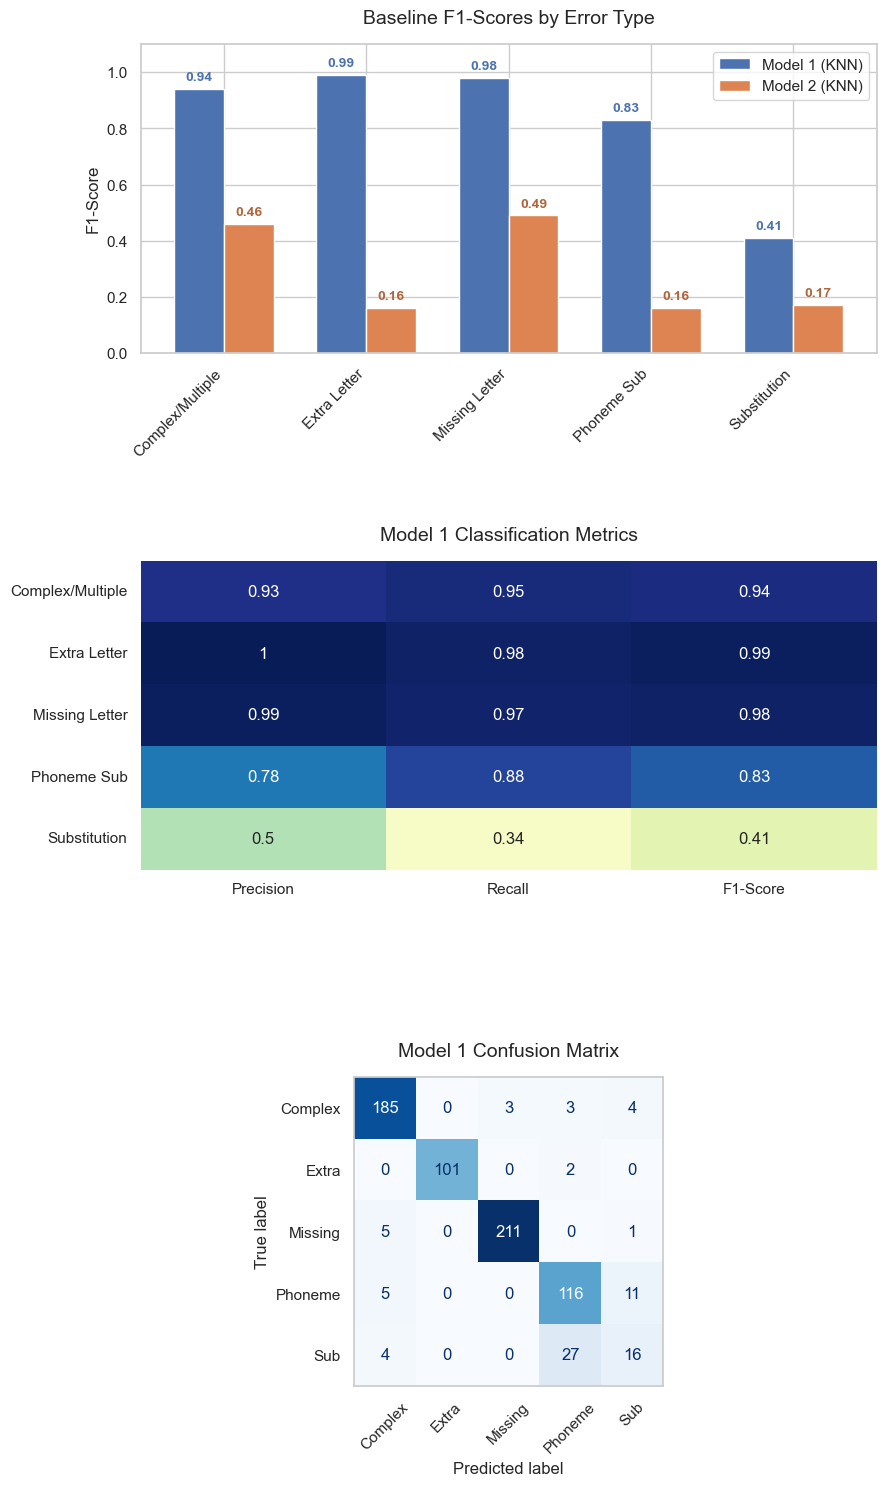

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Set overall aesthetic style
sns.set_theme(style="whitegrid")

# CHANGED: 3 rows, 1 column, and a taller figure size (10 width, 20 height)
fig, axes = plt.subplots(3, 1, figsize=(10, 16))

# --- Chart 1: F1-Score Comparison ---
categories = ['Complex/Multiple', 'Extra Letter', 'Missing Letter', 'Phoneme Sub', 'Substitution']
m1_f1 = [0.94, 0.99, 0.98, 0.83, 0.41]
m2_f1 = [0.46, 0.16, 0.49, 0.16, 0.17]

x = np.arange(len(categories))
width = 0.35

# Assign the bar plots to variables so we can iterate over them
bars1 = axes[0].bar(x - width/2, m1_f1, width, label='Model 1 (KNN)', color='#4C72B0')
bars2 = axes[0].bar(x + width/2, m2_f1, width, label='Model 2 (KNN)', color='#DD8452')

axes[0].set_ylabel('F1-Score')
axes[0].set_title('Baseline F1-Scores by Error Type', fontsize=14, pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, rotation=45, ha="right")
axes[0].set_ylim(0, 1.1)
axes[0].legend()

# Add numeric value labels on top of Model 1 (KNN) bars
for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#4C72B0')

# Add numeric value labels on top of Model 2 (KNN) bars
for bar in bars2:
    yval = bar.get_height()
    # Using a slightly darker shade of orange/brown for the text so it is readable
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#B0663D')

# --- Chart 2: Model 1 Diagnostic Heatmap ---
# Data from Model 1 classification report
m1_metrics = np.array([
    [0.93, 0.95, 0.94], # Complex/Multiple
    [1.00, 0.98, 0.99], # Extra Letter
    [0.99, 0.97, 0.98], # Missing Letter
    [0.78, 0.88, 0.83], # Phoneme Sub
    [0.50, 0.34, 0.41]  # Substitution
])

sns.heatmap(m1_metrics, annot=True, cmap="YlGnBu", vmin=0.3, vmax=1.0, 
            xticklabels=['Precision', 'Recall', 'F1-Score'], 
            yticklabels=categories, ax=axes[1], cbar=False)
axes[1].set_title('Model 1 Classification Metrics', fontsize=14, pad=15)

# --- Chart 3: Model 1 Confusion Matrix ---
labels = ['complex/multiple', 'extra_letter', 'missing_letter', 'phoneme_substitution', 'substitution']
cm = confusion_matrix(y_test, y_pred_m1, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Complex', 'Extra', 'Missing', 'Phoneme', 'Sub'])
disp.plot(cmap="Blues", ax=axes[2], colorbar=False, xticks_rotation=45)

axes[2].set_title('Model 1 Confusion Matrix', fontsize=14, pad=15)
axes[2].grid(False) # Turn off gridlines for confusion matrix

# CHANGED: Added padding to ensure labels between rows do not overlap
plt.tight_layout(pad=4.0)
plt.show()

### The F1-Score Comparison (Grouped Bar Chart)
- This is the most powerful chart. By plotting Model 1 and Model 2's F1-scores side-by-side for each error category, it visually demonstrates exactly where the baseline excels (missing/extra letters) and where it fundamentally breaks down (substitutions).

### Model 1 Diagnostic Heatmap
The heatmap of Model 1's Precision, Recall, and F1-score immediately draws the eye to the weakest link. The dark/cool spots on "substitution" will serve as visual proof that programmatic features cannot capture phonetic nuances.

### The Confusion Matrix
While the classification report gives percentages, a confusion matrix shows the actual number of misclassifications. It will clearly show how often the KNN confused a substitution for a phoneme_substitution.